In [1]:
import numpy as np
from astropy import units as u
from matplotlib import pyplot as plt

In [2]:
from spectrograph import *
from telescope import *
from detector import *

IMX183: Reading detector efficiency from /Users/jwalawender/git/SpecETC/data/SonyIMX/QE.csv
IMX533: Reading detector efficiency from /Users/jwalawender/git/SpecETC/data/SonyIMX/QE.csv


/Users/jwalawender/miniforge3/envs/py313/lib/python3.13/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in arcsin
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


# UVEX4

-10.7494931299665 deg 4.95036 arcsec 1836.0
-13.2741767299665 -8.224809529966501 0.0013751


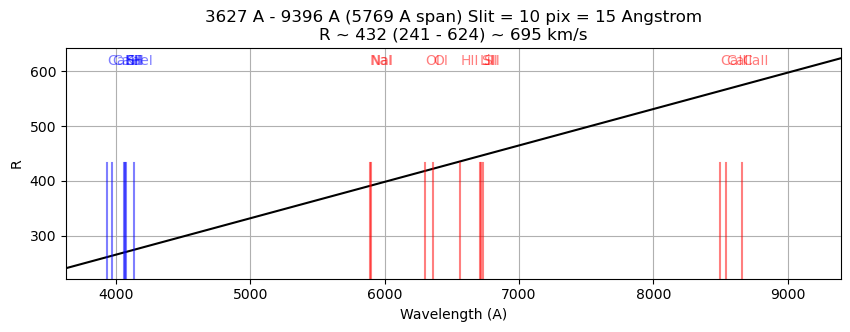

In [3]:
UVEX150.generate_binset(IMX183)
UVEX150.plot_coverage()

-8.934465746987186 deg 4.95036 arcsec 1836.0
-11.459149346987186 -6.409782146987187 0.0013751


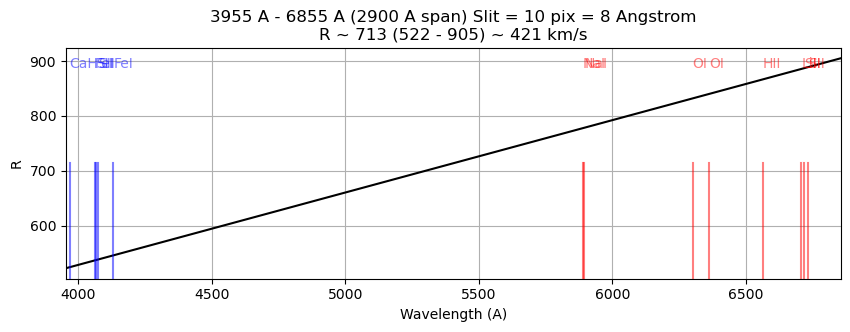

In [4]:
UVEX300.generate_binset(IMX183)
UVEX300.plot_coverage()

-7.2396715769744215 deg 4.95036 arcsec 1836.0
-9.764355176974421 -4.714987976974422 0.0013751


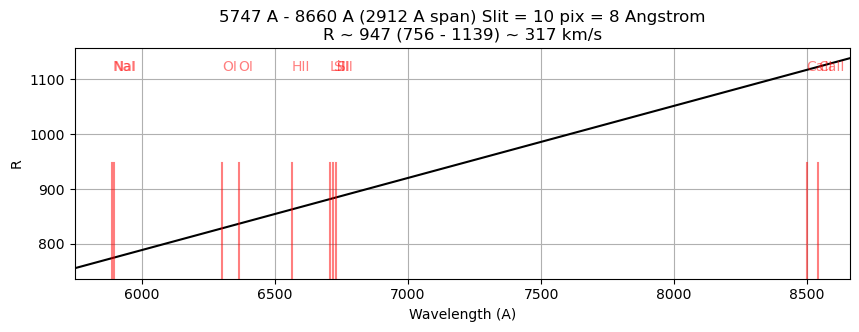

In [5]:
UVEX300R.generate_binset(IMX183)
UVEX300R.plot_coverage()

10.26405765617331 deg 4.95036 arcsec 1836.0
7.739374056173311 12.78874125617331 0.0013751


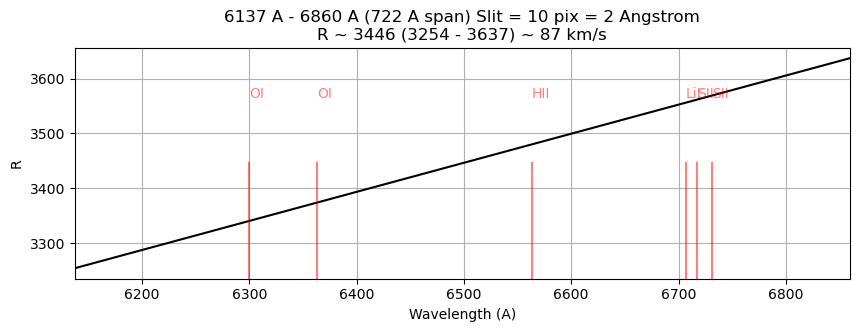

In [6]:
UVEX1200.generate_binset(IMX183)
UVEX1200.plot_coverage()

In [7]:
UVEX1800.cwav = 6550*u.Angstrom
UVEX1800.grating.alpha

<Quantity 0. deg>

In [8]:
UVEX1800.generate_binset(IMX183)
UVEX1800.plot_coverage()

nan deg 4.95036 arcsec 1836.0
nan nan 0.0013751


ValueError: arange: cannot compute length

# StarEx

In [ ]:
cwav = 6563*u.Angstrom

alpha0 = 40*u.degree
dalpha = 0.1
range_alpha = 40
alphas = np.arange(-range_alpha,range_alpha+dalpha,dalpha)+alpha0.to(u.degree).value
errs = []
for alpha in alphas:
    testspec = Spectrograph('StarEx600', 32*u.micron, 75*u.mm, 75*u.mm/3.5,
                              alpha*u.degree, 600/u.mm, 25*u.mm, 75*u.mm, 75*u.mm/3.5, 0.25)
    errs.append(abs((testspec.grating.alpha-testspec.grating.beta(cwav)-a_to_b).value))
opt = np.argmin(errs)

plt.figure(figsize=(10,3))
plt.plot(alphas, errs, 'bo-')
plt.axvline(alphas[opt], color='r', alpha=0.3, label=f'{alphas[opt]:.1f} deg')
plt.xlabel('alpha')
plt.ylabel('err')
plt.legend(loc='best')
plt.show()

StarEx600.grating.alpha-StarEx600.grating.beta(6563*u.Angstrom)

In [ ]:
StarEx.wav_from_beta(StarEx.beta(6563*u.Angstrom)).to(u.Angstrom), StarEx600.wav_from_beta(StarEx600.beta(6563*u.Angstrom)).to(u.Angstrom)

In [ ]:
StarEx600.get_geometric_efficiency(ACF14reduced, plot=True)

In [ ]:
StarEx600.generate_binset(IMX183)

In [ ]:
plt.plot(StarEx600.binset)

In [ ]:
StarEx.binset

In [ ]:
StarEx300 = SpecFromGratingEq('StarEx300', 20*u.micron, 75*u.mm, 75*u.mm/3.5,
                           50*u.deg, 300/u.mm, 25*u.mm, 75*u.mm, 75*u.mm/3.5, 0.25)


In [ ]:
StarEx300.beta(6563*u.Angstrom)

In [ ]:
StarEx300.alpha-beta

In [ ]:
StarEx300.generate_binset(IMX183)

In [ ]:
f"{min(StarEx300.binset):.0f} A - {max(StarEx300.binset):.0f} A"